# Verification: Trivalent Ligand-Bivalent Receptor Aggregation
# (Macken and Perelson, 1982)

Compares NFsim against:
1. **Kinetic ODEs** from Eq. 11 in Macken and Perelson (1982)
   for bond counts and free-site fractions.
2. **Branching process theory** (Theorem 1, Eqs. 6-7) for
   time-dependent aggregate size distributions $m_{ij}(t)$.
3. **Equilibrium aggregate distribution** from Eq. 21.
4. **Gelation condition** from Eq. 18.

Three ligand doses: low ($N_L = 420$), moderate ($N_L = 4200$),
high ($N_L = 42000$, prozone regime).

Lines = BNG NFsim (averaged), open markers = branching process
theory from ODE, red dashed = Eq. 21 equilibrium.

In [1]:
import subprocess, os, glob
import numpy as np
from numpy.polynomial import polynomial as P
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from math import comb
import matplotlib.pyplot as plt

os.chdir(os.path.dirname(os.path.abspath('__file__'))
         if '__file__' in dir() else '.')

NA = 6.02214076e23; V_ref = 1e-12; f_scale = 1.0
V_sim = V_ref * f_scale
NR = 300; ST = 2 * NR
koff = 0.01; kon = 1e6
kf = kon / (NA * V_sim)
kappa_ST = 0.5
kxf = kappa_ST / ST * koff
K1 = kf / koff; K2 = kxf / koff

NL_values = [420, 4200, 42000]
NL_labels = ['low', 'moderate', 'high']
t_end = 500; n_steps = 250

print(f'NR={NR}, ST={ST}, K1={K1:.4e}, K2={K2:.4e}')
print(f'kappa_ST={K2*ST:.4f}')

NR=300, ST=600, K1=1.6605e-04, K2=8.3333e-04
kappa_ST=0.5000


## 1. Kinetic ODEs (Eq. 11)

In [2]:
def macken1982_odes(t, y, kf_r, kxf_r, koff_r, NL_r, NR_r):
    L1, L2, L3 = y
    ST_r = 2 * NR_r
    L0 = NL_r - L1 - L2 - L3
    S = max(ST_r - (L1 + 2*L2 + 3*L3), 0)
    dL1 = 3*kf_r*L0*S - koff_r*L1 - 2*kxf_r*L1*S + 2*koff_r*L2
    dL2 = 2*kxf_r*L1*S - 2*koff_r*L2 - kxf_r*L2*S + 3*koff_r*L3
    dL3 = kxf_r*L2*S - 3*koff_r*L3
    return [dL1, dL2, dL3]

ode_results = {}
for NL_val, label in zip(NL_values, NL_labels):
    sol = solve_ivp(macken1982_odes, (0, t_end), [0, 0, 0],
                    args=(kf, kxf, koff, NL_val, NR),
                    method='BDF', rtol=1e-10, atol=1e-12,
                    t_eval=np.linspace(0, t_end, n_steps+1))
    L1, L2, L3 = sol.y
    Bonds = L1 + 2*L2 + 3*L3
    ode_results[label] = dict(t=sol.t, L1=L1, L2=L2, L3=L3,
                              Bonds=Bonds, S=ST-Bonds, NL=NL_val)
    print(f'{label}: Bonds_eq={Bonds[-1]:.1f}, '
          f'L1={L1[-1]:.1f}, L2={L2[-1]:.1f}, L3={L3[-1]:.1f}')

low: Bonds_eq=138.3, L1=72.3, L2=27.7, L3=3.5


moderate: Bonds_eq=428.1, L1=327.5, L2=46.9, L3=2.2


high: Bonds_eq=573.4, L1=548.8, L2=12.2, L3=0.1


## 2. Branching Process Theory (Theorem 1)

The aggregate size distribution $m_{ij}(t)$ — the number of
aggregates with $i$ receptors and $j$ ligands — is computed
from the instantaneous bond-count distribution using the
generating functions $F_R(u_L)$ and $F_L(u_R)$ (Eq. 4) and
the coefficient extraction in Eqs. 6-7.

For $g=2$: $F_R(u_L) = (1-p) + p u_L$ where $p = b/S_0$.

For $f=3$: $F_L(u_R) = \frac{1}{M_L}[p_{L1} + 2p_{L2}u_R
+ 3p_{L3}u_R^2]$.

Weight fractions from Eqs. 6-7 (with exponents $j$ on $F_L$
and $i$ on $F_R$ in Eq. 6, and $i$ on $F_R$ and $j$ on $F_L$
in Eq. 7), combined via Eq. 1 and converted to aggregate
counts via Eq. 20.

In [3]:
def polypow(c, n):
    """Polynomial c raised to power n."""
    if n == 0:
        return np.array([1.0])
    r = c.copy()
    for _ in range(n - 1):
        r = P.polymul(r, c)
    return r

def pcoeff(poly, k):
    """Coefficient of x^k in polynomial."""
    return poly[k] if k < len(poly) else 0.0


def compute_mij(i, j, L1v, L2v, L3v, NL_v, NR_v):
    """Compute m_{ij} via Theorem 1 of Macken and Perelson
    (1982). Uses generating function coefficient extraction
    from Eqs. 6-7 with polynomial arithmetic."""
    ST_v = 2 * NR_v
    bonds = L1v + 2*L2v + 3*L3v
    if bonds < 1e-30:
        if i == 1 and j == 0: return float(NR_v)
        if i == 0 and j == 1: return float(NL_v)
        return 0.0

    L0v = NL_v - L1v - L2v - L3v
    p = bonds / ST_v
    pL = np.array([L0v, L1v, L2v, L3v]) / NL_v
    ML = bonds / NL_v
    MR = 2 * p
    rho = NR_v / (NR_v + NL_v)

    pR = np.array([(1-p)**2, 2*p*(1-p), p**2])
    FR = np.array([1-p, p])
    FL = np.array([pL[1]/ML, 2*pL[2]/ML, 3*pL[3]/ML])

    # --- w_R from Eq. 6 ---
    if j == 0:
        wR = pR[0] if i == 1 else 0.0
    elif i == 1:
        wR = ((pR[j] if j < len(pR) else 0.0) *
              pcoeff(polypow(FL, j), 0))
    elif i >= 2 and j >= 1:
        dFLj = P.polyder(polypow(FL, j))
        FRi = polypow(FR, i)
        wR = MR / ((i-1)*j) * pcoeff(dFLj, i-2) * \
             pcoeff(FRi, j-1)
    else:
        wR = 0.0

    # --- w_L from Eq. 7 ---
    if i == 0:
        wL = pL[0] if j == 1 else 0.0
    elif j == 1:
        wL = ((pL[i] if i < len(pL) else 0.0) *
              pcoeff(polypow(FR, i), 0))
    elif j >= 2 and i >= 1:
        dFRi = P.polyder(polypow(FR, i))
        FLj = polypow(FL, j)
        wL = ML / ((j-1)*i) * pcoeff(dFRi, j-2) * \
             pcoeff(FLj, i-1)
    else:
        wL = 0.0

    wij = rho * wR + (1 - rho) * wL
    return wij * (NR_v + NL_v) / (i + j)


# Compute m_{ij}(t) from ODE at each time step
agg_types = [(1,1), (2,1), (3,1), (1,2)]
agg_labels = ['$m_{1,1}$', '$m_{2,1}$',
              '$m_{3,1}$', '$m_{1,2}$']
bp_results = {}
for NL_val, label in zip(NL_values, NL_labels):
    ode = ode_results[label]
    bp = {}
    for (ai, aj) in agg_types:
        key = f'm_{ai}_{aj}'
        vals = np.array([
            compute_mij(ai, aj, ode['L1'][k], ode['L2'][k],
                        ode['L3'][k], NL_val, NR)
            for k in range(len(ode['t']))])
        bp[key] = vals
    bp_results[label] = bp
    print(f'{label} equil: '
          + ', '.join(f'm_{ai}_{aj}={bp[f"m_{ai}_{aj}"][-1]:.2f}'
                      for ai, aj in agg_types))

low equil: m_1_1=55.61, m_2_1=16.40, m_3_1=1.61, m_1_2=4.35


moderate equil: m_1_1=93.85, m_2_1=3.85, m_3_1=0.05, m_1_2=89.37
high equil: m_1_1=24.32, m_2_1=0.02, m_3_1=0.00, m_1_2=251.01


## 3. Equilibrium Theory (Eqs. 13, 17, 21)

In [4]:
def macken_eq21(i, j, K1v, K2v, C_free, S_free, ST_v):
    """Eq. 21: equilibrium aggregate concentration."""
    g, f, v = 2, 3, 3
    return (ST_v / (i * j) *
            comb((g-1)*i, j-1) * comb((f-1)*j, i-1) *
            (v * K1v * C_free)**j *
            (K2v * ST_v)**(i-1) *
            (S_free / ST_v)**(g * i))

eq = {}
for NL_val, label in zip(NL_values, NL_labels):
    def eq_residual(S_val, NL_r=NL_val):
        D = 1 + K1*S_val*(3 + 3*K2*S_val + K2**2*S_val**2)
        C_free = NL_r / D
        bonds = 3*K1*C_free*S_val*(1 + K2*S_val)**2
        return S_val - (ST - bonds)

    S_eq = brentq(eq_residual, 1e-10, ST - 1e-10)
    D_eq = 1 + K1*S_eq*(3 + 3*K2*S_eq + K2**2*S_eq**2)
    C_eq = NL_val / D_eq
    Bonds_eq = ST - S_eq
    gel = 2*K1*C_eq*K2*S_eq**2*(1 + K2*S_eq) / ST

    eq_agg = {}
    for (ai, aj) in agg_types:
        eq_agg[f'm_{ai}_{aj}'] = macken_eq21(
            ai, aj, K1, K2, C_eq, S_eq, ST)

    eq[label] = dict(S=S_eq, C=C_eq, Bonds=Bonds_eq,
                     gel=gel, **eq_agg)
    print(f'{label}: gel={gel:.4f}, '
          + ', '.join(f'm_{ai}_{aj}={eq_agg[f"m_{ai}_{aj}"]:.2f}'
                      for ai, aj in agg_types))

low: gel=0.0429, m_1_1=55.75, m_2_1=16.45, m_3_1=1.62, m_1_2=4.39
moderate: gel=0.0596, m_1_1=93.85, m_2_1=3.85, m_3_1=0.05, m_1_2=89.37
high: gel=0.0138, m_1_1=24.32, m_2_1=0.02, m_3_1=0.00, m_1_2=251.01


## 4. Run NFsim

In [5]:
bngl_file = ('trivalent_ligand_bivalent_receptor_'
             'aggregation_macken1982.bngl')
with open(bngl_file) as fh:
    bngl_template = fh.read()

N_RUNS = 10
nf = {}
for NL_val, label in zip(NL_values, NL_labels):
    tmp = bngl_template.replace(
        'NL  4200  # molecules',
        f'NL  {NL_val}  # molecules')
    tmp = tmp.replace('suffix=>"nfr"',
                      f'suffix=>"nfr_{label}"')
    tmp_file = f'tmp_{label}.bngl'
    with open(tmp_file, 'w') as fh:
        fh.write(tmp)

    print(f'Running {label} (NL={NL_val}, '
          f'{N_RUNS} reps)...', flush=True)
    all_data = []
    for i in range(N_RUNS):
        result = subprocess.run(
            ['bionetgen', 'run', '-i', tmp_file],
            capture_output=True, text=True, timeout=600)
        gdat = f'tmp_{label}_nfr_{label}.gdat'
        if os.path.exists(gdat):
            all_data.append(np.loadtxt(gdat, comments='#'))

    if all_data:
        md = np.mean(np.array(all_data), axis=0)
        nf[label] = dict(
            t=md[:,0], Free_L=md[:,1], Free_R=md[:,2],
            Bonds=md[:,3], Free_L_sites=md[:,4],
            Free_R_sites=md[:,5],
            m_1_1=md[:,6], m_2_1=md[:,7],
            m_3_1=md[:,8], m_1_2=md[:,9],
            NL=NL_val)
        print(f'  {len(all_data)} runs, '
              f'Bonds~{md[-30:,3].mean():.0f}, '
              f'm_11~{md[-30:,6].mean():.1f}, '
              f'm_21~{md[-30:,7].mean():.1f}')
    else:
        print('  FAILED')

for fn in glob.glob('tmp_*'):
    os.remove(fn)

Running low (NL=420, 10 reps)...


  10 runs, Bonds~141, m_11~57.6, m_21~16.5
Running moderate (NL=4200, 10 reps)...


  10 runs, Bonds~426, m_11~93.6, m_21~4.4
Running high (NL=42000, 10 reps)...


  10 runs, Bonds~574, m_11~23.9, m_21~0.0


## 5. Bond Kinetics Comparison

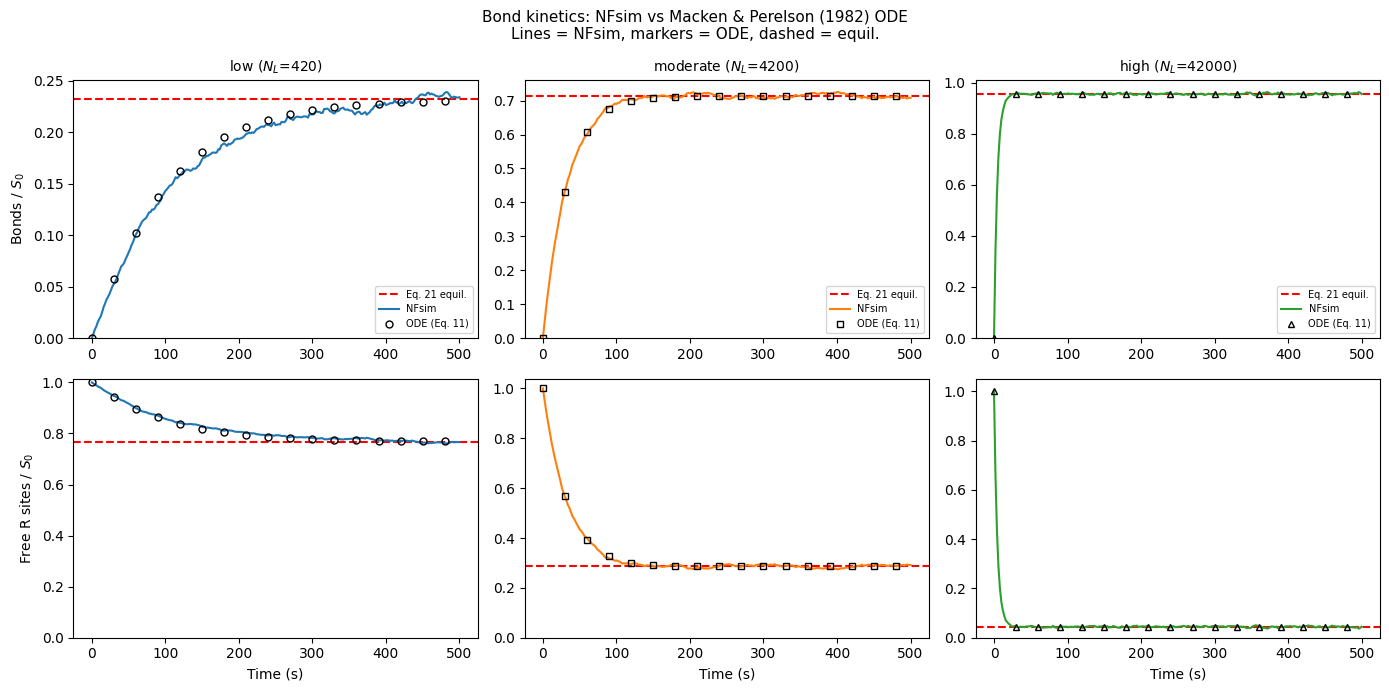

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
colors = {'low': 'C0', 'moderate': 'C1', 'high': 'C2'}
mkrs = {'low': 'o', 'moderate': 's', 'high': '^'}

for col, label in enumerate(NL_labels):
    ode = ode_results[label]; e = eq[label]
    idx = np.arange(0, len(ode['t']), 15)

    ax = axes[0, col]
    ax.axhline(e['Bonds']/ST, color='r', ls='--', lw=1.5,
               label='Eq. 21 equil.')
    if label in nf:
        ax.plot(nf[label]['t'], nf[label]['Bonds']/ST, '-',
                color=colors[label], lw=1.5, label='NFsim')
    ax.plot(ode['t'][idx], ode['Bonds'][idx]/ST,
            mkrs[label], mfc='none', mec='k', ms=5,
            label='ODE (Eq. 11)')
    ax.set_ylabel('Bonds / $S_0$' if col==0 else '')
    ax.set_title(f'{label} ($N_L$={ode["NL"]})', fontsize=10)
    ax.legend(fontsize=7); ax.set_ylim(bottom=0)

    ax = axes[1, col]
    ax.axhline(e['S']/ST, color='r', ls='--', lw=1.5)
    if label in nf:
        ax.plot(nf[label]['t'], nf[label]['Free_R_sites']/ST,
                '-', color=colors[label], lw=1.5)
    ax.plot(ode['t'][idx], ode['S'][idx]/ST,
            mkrs[label], mfc='none', mec='k', ms=5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Free R sites / $S_0$' if col==0 else '')
    ax.set_ylim(bottom=0)

fig.suptitle('Bond kinetics: NFsim vs Macken & Perelson '
             '(1982) ODE\n'
             'Lines = NFsim, markers = ODE, '
             'dashed = equil.', fontsize=11)
fig.tight_layout()
fig.savefig('verify_macken1982.png', dpi=150,
            bbox_inches='tight')
plt.show()

## 6. Aggregate Distribution Kinetics (Branching Process)

The key test: compare NFsim aggregate counts against
Theorem 1 predictions computed from the ODE bond
distributions. These predictions require the full
branching process machinery — they cannot be obtained
from bond counts alone.

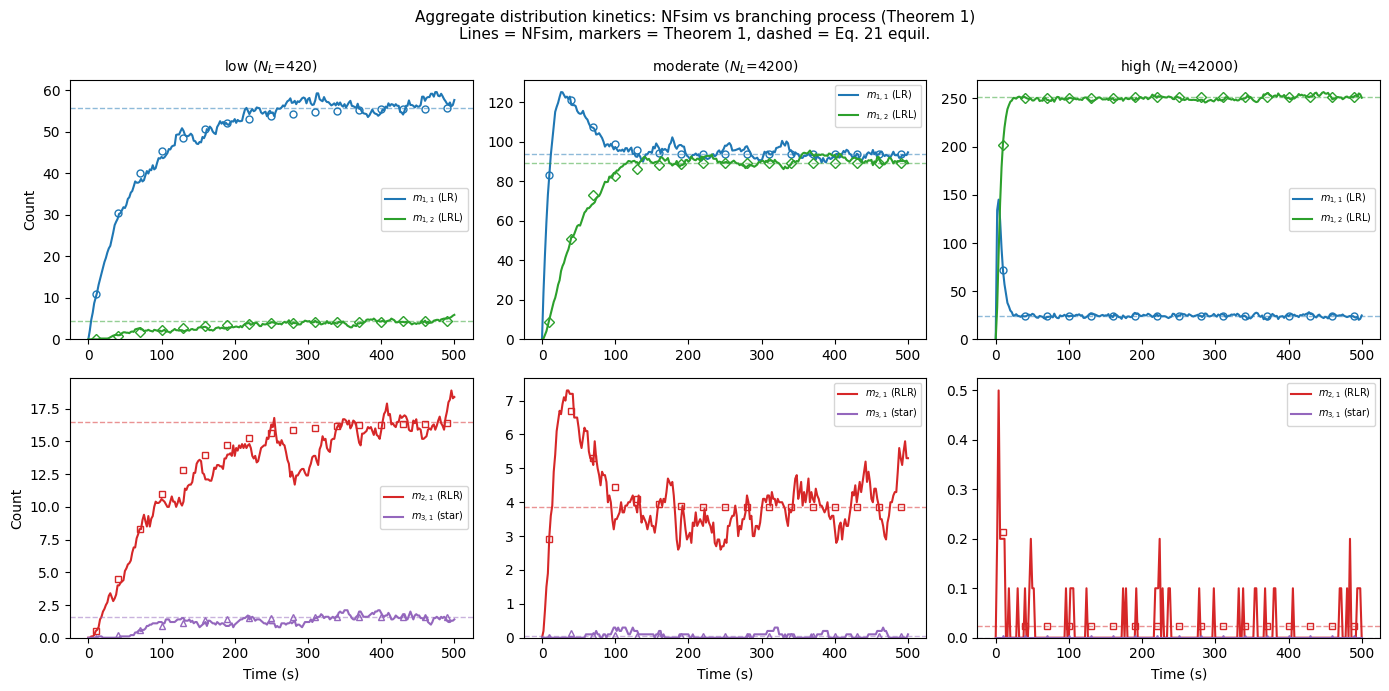

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
agg_colors = {'m_1_1': 'C0', 'm_2_1': 'C3',
              'm_3_1': 'C4', 'm_1_2': 'C2'}
agg_mkrs = {'m_1_1': 'o', 'm_2_1': 's',
            'm_3_1': '^', 'm_1_2': 'D'}
agg_nice = {'m_1_1': '$m_{1,1}$ (LR)',
            'm_2_1': '$m_{2,1}$ (RLR)',
            'm_3_1': '$m_{3,1}$ (star)',
            'm_1_2': '$m_{1,2}$ (LRL)'}

for col, label in enumerate(NL_labels):
    ode = ode_results[label]; e = eq[label]
    bp = bp_results[label]
    idx = np.arange(5, len(ode['t']), 15)

    # Top: m_{1,1} and m_{1,2} (large counts)
    ax = axes[0, col]
    for key in ['m_1_1', 'm_1_2']:
        c = agg_colors[key]; m = agg_mkrs[key]
        ax.axhline(e[key], color=c, ls='--', lw=1,
                   alpha=0.5)
        if label in nf:
            ax.plot(nf[label]['t'], nf[label][key], '-',
                    color=c, lw=1.5, label=agg_nice[key])
        ax.plot(ode['t'][idx], bp[key][idx], m,
                mfc='none', mec=c, ms=5)
    ax.set_ylabel('Count' if col==0 else '')
    ax.set_title(f'{label} ($N_L$={ode["NL"]})', fontsize=10)
    ax.legend(fontsize=7); ax.set_ylim(bottom=0)

    # Bottom: m_{2,1} and m_{3,1} (small counts)
    ax = axes[1, col]
    for key in ['m_2_1', 'm_3_1']:
        c = agg_colors[key]; m = agg_mkrs[key]
        ax.axhline(e[key], color=c, ls='--', lw=1,
                   alpha=0.5)
        if label in nf:
            ax.plot(nf[label]['t'], nf[label][key], '-',
                    color=c, lw=1.5, label=agg_nice[key])
        ax.plot(ode['t'][idx], bp[key][idx], m,
                mfc='none', mec=c, ms=5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Count' if col==0 else '')
    ax.legend(fontsize=7); ax.set_ylim(bottom=0)

fig.suptitle('Aggregate distribution kinetics: NFsim vs '
             'branching process (Theorem 1)\n'
             'Lines = NFsim, markers = Theorem 1, '
             'dashed = Eq. 21 equil.', fontsize=11)
fig.tight_layout()
fig.savefig('verify_macken1982_aggregates.png', dpi=150,
            bbox_inches='tight')
plt.show()

## 7. Error Summary

In [8]:
n_eq = 30
max_rel = 0

print('=== Bond kinetics (NFsim vs theory) ===')
print(f'{"Dose":>10s} {"Bonds/S0":>10s} {"S/S0":>10s}')
print(f'{"":>10s} {"Thy":>5s} {"NF":>5s}  '
      f'{"Thy":>5s} {"NF":>5s}')
print('-' * 40)
for label in NL_labels:
    e = eq[label]
    if label not in nf: continue
    r = nf[label]
    B_t = e['Bonds']/ST; B_n = r['Bonds'][-n_eq:].mean()/ST
    S_t = e['S']/ST; S_n = r['Free_R_sites'][-n_eq:].mean()/ST
    for val_t, val_n in [(B_t, B_n), (S_t, S_n)]:
        if val_t > 1e-10:
            max_rel = max(max_rel, abs(val_n-val_t)/val_t)
    print(f'{label:>10s} {B_t:5.3f} {B_n:5.3f}  '
          f'{S_t:5.3f} {S_n:5.3f}')

print('\n=== Aggregate counts (NFsim vs Theorem 1 / '
      'Eq. 21) ===')
print(f'{"Dose":>10s}', end='')
for ai, aj in agg_types:
    print(f'  m_{ai}{aj}(Thy/NF)', end='')
print()
print('-' * 75)
for label in NL_labels:
    e = eq[label]
    print(f'{label:>10s}', end='')
    if label not in nf:
        print('  (no data)'); continue
    r = nf[label]
    for ai, aj in agg_types:
        key = f'm_{ai}_{aj}'
        thy = e[key]
        nfv = r[key][-n_eq:].mean()
        if thy > 0.5:
            rel = abs(nfv - thy) / thy
            max_rel = max(max_rel, rel)
        print(f'  {thy:6.1f}/{nfv:6.1f}', end='')
    print()

print(f'\nMax relative error: {max_rel:.4f}')
print(f'Gelation: ', end='')
for label in NL_labels:
    print(f'{label}={eq[label]["gel"]:.3f}  ', end='')
print()

if max_rel < 0.15:
    print('\nPASS: NFsim agrees with Macken & Perelson '
          '(1982) branching process theory.')
else:
    print('\nFAIL: Significant disagreement detected.')

=== Bond kinetics (NFsim vs theory) ===
      Dose   Bonds/S0       S/S0
             Thy    NF    Thy    NF
----------------------------------------
       low 0.232 0.236  0.768 0.764
  moderate 0.713 0.709  0.287 0.291
      high 0.956 0.956  0.044 0.044

=== Aggregate counts (NFsim vs Theorem 1 / Eq. 21) ===
      Dose  m_11(Thy/NF)  m_21(Thy/NF)  m_31(Thy/NF)  m_12(Thy/NF)
---------------------------------------------------------------------------
       low    55.8/  57.6    16.5/  16.5     1.6/   1.4     4.4/   4.5
  moderate    93.8/  93.6     3.9/   4.4     0.1/   0.1    89.4/  90.2
      high    24.3/  23.9     0.0/   0.0     0.0/   0.0   251.0/ 252.3

Max relative error: 0.1332
Gelation: low=0.043  moderate=0.060  high=0.014  

PASS: NFsim agrees with Macken & Perelson (1982) branching process theory.
